# Deep Learning — Multiple NN Architectures, LSTM Baseline, and DistilBERT Fine-Tuning (LoRA)
### Hotel Review Sentiment Classification

Standalone notebook — self-contained, does not depend on the teammate's ML/EDA notebook. Loads the raw dataset and repeats the same preprocessing used for the classical ML track (so results are directly comparable), then covers everything DL-specific:
1. **Five NN architectures** (shallow, deep, deep+BatchNorm, wide, 1D-CNN) — the deep learning floor, compared against each other.
2. An **LSTM baseline** (Bidirectional, from scratch) — the RNN-era comparison point.
3. **DistilBERT fine-tuned with LoRA** — the transformer-era model.

**Local execution note:** every model uses a chunked `tf.data.Dataset` pipeline (`.batch().prefetch()`) instead of loading full arrays into the model at once, and memory is explicitly cleared (`clear_session()` + `gc.collect()`) between models. Run and confirm each model's cells before moving to the next block if your machine has limited RAM/VRAM — the notebook is structured so each architecture is fully self-contained and can be run independently.

Every preprocessing/feature-selection decision is validated with a printed check immediately after it's made.

## 1) Imports & Setup

In [1]:
#!pip install keras-hub tensorflow scikit-learn pandas numpy matplotlib --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import gc

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, log_loss, roc_auc_score, classification_report

# Keras / TensorFlow imports
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping

# Keras Hub (Transformer) imports
import keras_hub

## 2) Load Data
Dataset: 515K Hotel Reviews Data in Europe (jiashenliu, Kaggle) — https://www.kaggle.com/datasets/jiashenliu/515k-hotel-reviews-data-in-europe

In [3]:
df_hotel_reviews = pd.read_csv("/content/Hotel_Reviews.csv")

print("Shape:", df_hotel_reviews.shape)
print("\nColumns:", df_hotel_reviews.columns.tolist())
print("\nNull counts:\n", df_hotel_reviews.isnull().sum())
df_hotel_reviews.head()


Shape: (515738, 17)

Columns: ['Hotel_Address', 'Additional_Number_of_Scoring', 'Review_Date', 'Average_Score', 'Hotel_Name', 'Reviewer_Nationality', 'Negative_Review', 'Review_Total_Negative_Word_Counts', 'Total_Number_of_Reviews', 'Positive_Review', 'Review_Total_Positive_Word_Counts', 'Total_Number_of_Reviews_Reviewer_Has_Given', 'Reviewer_Score', 'Tags', 'days_since_review', 'lat', 'lng']

Null counts:
 Hotel_Address                                    0
Additional_Number_of_Scoring                     0
Review_Date                                      0
Average_Score                                    0
Hotel_Name                                       0
Reviewer_Nationality                             0
Negative_Review                                  0
Review_Total_Negative_Word_Counts                0
Total_Number_of_Reviews                          0
Positive_Review                                  0
Review_Total_Positive_Word_Counts                0
Total_Number_of_Reviews_Revi

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968


## 3) Preprocessing
Same cleaning logic as the classical ML notebook, kept identical on purpose so all three tracks (ML, LSTM, DistilBERT) train/evaluate on the same target definition and the same text field.

In [4]:
df_hotel_reviews['Negative_Review'] = df_hotel_reviews['Negative_Review'].str.strip()
df_hotel_reviews['Positive_Review'] = df_hotel_reviews['Positive_Review'].str.strip()

df_hotel_reviews.loc[:, 'Positive_Review'] = df_hotel_reviews.Positive_Review.apply(
    lambda x: x.replace('No Positive', ''))
df_hotel_reviews.loc[:, 'Negative_Review'] = df_hotel_reviews.Negative_Review.apply(
    lambda x: x.replace('No Negative', ''))

df_hotel_reviews['review'] = df_hotel_reviews['Positive_Review'] + " " + df_hotel_reviews['Negative_Review']

df_hotel_reviews['review_type'] = df_hotel_reviews['Reviewer_Score'].apply(
    lambda x: 'bad' if x < 7 else 'good')

df_reviews = df_hotel_reviews[['review', 'review_type']]
print(df_reviews.head())
print("\nReview type distribution (before resampling):\n", df_reviews.review_type.value_counts())


                                              review review_type
0  Only the park outside of the hotel was beautif...         bad
1  No real complaints the hotel was great great l...        good
2  Location was good and staff were ok It is cute...        good
3  Great location in nice surroundings the bar an...         bad
4  Amazing location and building Romantic setting...         bad

Review type distribution (before resampling):
 review_type
good    428887
bad      86851
Name: count, dtype: int64


### Balance classes via undersampling
Matches the ML notebook's approach — undersample the majority class ('good') to match the minority class count.

In [5]:

good_reviews = df_reviews[df_reviews.review_type == 'good']
bad_reviews = df_reviews[df_reviews.review_type == 'bad']
print(f"Good reviews: {len(good_reviews)}, Bad reviews: {len(bad_reviews)}")

good_df = good_reviews.sample(n=len(bad_reviews), random_state=42)
df_review_resampled = pd.concat([good_df, bad_reviews]).reset_index(drop=True)

print("\nResampled shape:", df_review_resampled.shape)
print("Resampled class distribution:\n", df_review_resampled.review_type.value_counts())


Good reviews: 428887, Bad reviews: 86851

Resampled shape: (173702, 2)
Resampled class distribution:
 review_type
good    86851
bad     86851
Name: count, dtype: int64


## 4) Label Encoding & Train/Test Split

In [6]:
label_enc = LabelEncoder()
encoded_review = label_enc.fit_transform(df_review_resampled.review_type.values)

print("Label classes:", list(label_enc.classes_))
print("Encoding mapping:", dict(zip(label_enc.classes_, label_enc.transform(label_enc.classes_))))

train_reviews, test_reviews, y_train, y_test = train_test_split(
    df_review_resampled.review,
    encoded_review,
    test_size=0.25,
    random_state=42
)

print("\nTrain size:", len(train_reviews), " Test size:", len(test_reviews))
print("Train label balance:", np.bincount(y_train))
print("Test label balance:", np.bincount(y_test))


Label classes: ['bad', 'good']
Encoding mapping: {'bad': np.int64(0), 'good': np.int64(1)}

Train size: 130276  Test size: 43426
Train label balance: [65129 65147]
Test label balance: [21722 21704]


## 5) Validate Inputs & Review Length Distribution
Used to pick both the LSTM's `max_len`/vocab size and DistilBERT's `max_length` later — one validated decision, reused for both models rather than guessed twice.

Sample raw review:
 Stylish hotel great view from floor to ceiling window in 10th floor bedroom 

Word count distribution:
 count    130276.000000
mean         38.807463
std          44.808350
min           0.000000
25%          12.000000
50%          25.000000
75%          49.000000
max         733.000000
Name: review, dtype: float64


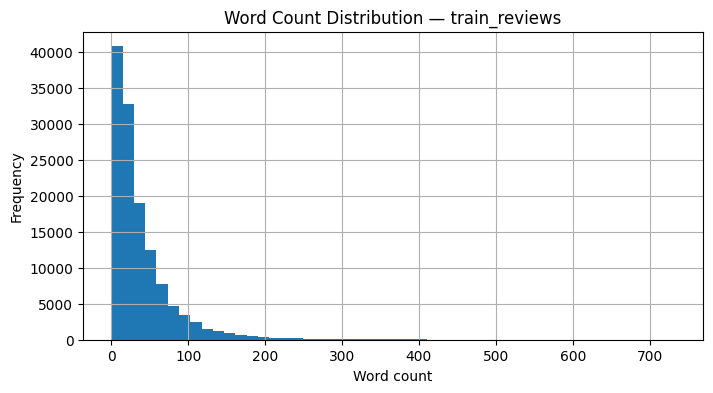


% of reviews with <= 128 words: 95.70%
-> If this is high (>90%), max_length=128 is a safe truncation choice for both models below.


In [7]:
print("Sample raw review:\n", train_reviews.iloc[0][:300])

review_lengths = train_reviews.apply(lambda x: len(x.split()))
print("\nWord count distribution:\n", review_lengths.describe())

plt.figure(figsize=(8,4))
review_lengths.hist(bins=50)
plt.title("Word Count Distribution — train_reviews")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.savefig("dl_review_length_distribution.png")
plt.show()

pct_under_128 = (review_lengths <= 128).mean() * 100
print(f"\n% of reviews with <= 128 words: {pct_under_128:.2f}%")
print("-> If this is high (>90%), max_length=128 is a safe truncation choice for both models below.")


# Part A0 — Neural Network Architectures (Multiple Variants)

Several feedforward NN architectures, each trained and evaluated separately, before the LSTM/DistilBERT sections. This gives a real "plain NN" comparison spread — shallow vs deep vs wide vs regularized vs convolutional — rather than a single arbitrary architecture.

**Local-machine execution note:** each model below uses a `tf.data.Dataset` pipeline with `.batch()` and `.prefetch()` so training data is streamed in chunks rather than held fully in memory as one array, and `tf.keras.backend.clear_session()` + `gc.collect()` run after every model to free GPU/RAM before the next one starts. Run each model's cells as its own block — finish and confirm one model's output before moving to the next, rather than running the whole notebook in one go, if memory is tight.

## A0.1) Shared Tokenization (reused by all NN variants + LSTM)

In [8]:
import gc

VOCAB_SIZE = 20000
MAX_LEN = 128   # matches the word-length validation done earlier
BATCH_SIZE = 64

keras_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
keras_tokenizer.fit_on_texts(train_reviews)

train_seq = keras_tokenizer.texts_to_sequences(train_reviews)
test_seq = keras_tokenizer.texts_to_sequences(test_reviews)

X_train_nn = pad_sequences(train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_nn = pad_sequences(test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print("X_train_nn shape:", X_train_nn.shape)
print("X_test_nn shape:", X_test_nn.shape)
print("Actual vocabulary size found:", len(keras_tokenizer.word_index))


X_train_nn shape: (130276, 128)
X_test_nn shape: (43426, 128)
Actual vocabulary size found: 43798


### Validate tokenization output
Decode a padded sequence back to words — confirms the pipeline matches the original text.

In [9]:
index_word = {v: k for k, v in keras_tokenizer.word_index.items()}

def decode_sequence(seq):
    return ' '.join(index_word.get(i, '') for i in seq if i != 0)

sample_idx = 0
print("Original text (first 300 chars):\n", train_reviews.iloc[sample_idx][:300])
print("\nDecoded back from padded sequence:\n", decode_sequence(X_train_nn[sample_idx])[:300])
print("\nNon-zero (real) tokens in this padded sequence:", np.count_nonzero(X_train_nn[sample_idx]))


Original text (first 300 chars):
 Stylish hotel great view from floor to ceiling window in 10th floor bedroom 

Decoded back from padded sequence:
 stylish hotel great view from floor to ceiling window in 10th floor bedroom

Non-zero (real) tokens in this padded sequence: 13


### Build chunked `tf.data` pipelines
Streams data in batches instead of loading the full array into the model at once — this is what keeps memory usage flat regardless of dataset size on a local machine.

In [10]:
def make_dataset(X, y, batch_size=BATCH_SIZE, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(X), 10000))
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds_nn = make_dataset(X_train_nn, y_train, shuffle=True)
test_ds_nn = make_dataset(X_test_nn, y_test, shuffle=False)

print("Batches per epoch (train):", tf.data.experimental.cardinality(train_ds_nn).numpy())
print("Batches per epoch (test):", tf.data.experimental.cardinality(test_ds_nn).numpy())


Batches per epoch (train): 2036
Batches per epoch (test): 679


### Shared evaluation helper
One function reused by every NN variant below, so all results print in the exact same format as `model_predict()` used for classical ML — needed for the final comparison table.

In [11]:
def evaluate_nn(name, model, X_test, y_test):
    probs = model.predict(X_test, verbose=0).flatten()
    preds = (probs >= 0.5).astype(int)
    probs_2class = np.column_stack([1 - probs, probs])

    print(f"{name}\n")
    print(f"logloss\n: {log_loss(y_test, probs_2class):0.3f}")
    print(f"ROC AUC\n: {roc_auc_score(y_test, probs):0.3f}")
    print("classification Report:\n", classification_report(y_test, preds))

    return {
        "Model": name,
        "LogLoss": log_loss(y_test, probs_2class),
        "ROC_AUC": roc_auc_score(y_test, probs),
        "Accuracy": accuracy_score(y_test, preds),
        "F1_Macro": f1_score(y_test, preds, average='macro'),
    }

def free_memory():
    tf.keras.backend.clear_session()
    gc.collect()
    print("Session cleared, memory freed.")

nn_results = []   # collects every NN variant's result for the final comparison table


## A0.2) Variant 1 — Shallow NN (1 hidden layer)
Simplest possible NN: embedding -> pooling -> one Dense layer. This is the true floor.

In [12]:
EMBEDDING_DIM = 128

shallow_nn = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    GlobalAveragePooling1D(),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

shallow_nn.compile(optimizer='adam', loss='binary_crossentropy',
                    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
shallow_nn.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
shallow_history = shallow_nn.fit(train_ds_nn, validation_data=test_ds_nn,
                                  epochs=10, callbacks=[early_stop], verbose=1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.7654 - auc: 0.8544 - loss: 0.4708 - val_accuracy: 0.7870 - val_auc: 0.8966 - val_loss: 0.4453
Epoch 2/10
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8121 - auc: 0.8972 - loss: 0.4026 - val_accuracy: 0.8127 - val_auc: 0.9013 - val_loss: 0.4044
Epoch 3/10
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.8205 - auc: 0.9050 - loss: 0.3882 - val_accuracy: 0.8108 - val_auc: 0.9021 - val_loss: 0.4017
Epoch 4/10
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8239 - auc: 0.9083 - loss: 0.3816 - val_accuracy: 0.7889 - val_auc: 0.9016 - val_loss: 0.4451
Epoch 5/10
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8308 - auc: 0.9144 - loss: 0.3691 - val_accuracy: 0.8126 - val_auc: 0.9031 - val_loss: 0.4030


In [13]:
nn_results.append(evaluate_nn("Shallow NN (1 hidden layer)", shallow_nn, X_test_nn, y_test))
free_memory()   # clear before building the next model


Shallow NN (1 hidden layer)

logloss
: 0.402
ROC AUC
: 0.902
classification Report:
               precision    recall  f1-score   support

           0       0.84      0.77      0.80     21722
           1       0.79      0.85      0.82     21704

    accuracy                           0.81     43426
   macro avg       0.81      0.81      0.81     43426
weighted avg       0.81      0.81      0.81     43426

Session cleared, memory freed.


## A0.3) Variant 2 — Deep NN (4 hidden layers)
Same input pipeline, deeper stack of Dense layers with dropout between each.

In [14]:
deep_nn = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    GlobalAveragePooling1D(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

deep_nn.compile(optimizer='adam', loss='binary_crossentropy',
                 metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
deep_nn.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
deep_history = deep_nn.fit(train_ds_nn, validation_data=test_ds_nn,
                            epochs=10, callbacks=[early_stop], verbose=1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.7569 - auc: 0.8451 - loss: 0.4849 - val_accuracy: 0.8155 - val_auc: 0.8988 - val_loss: 0.4031
Epoch 2/10
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8077 - auc: 0.8911 - loss: 0.4159 - val_accuracy: 0.8154 - val_auc: 0.9019 - val_loss: 0.4009
Epoch 3/10
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8156 - auc: 0.8993 - loss: 0.4006 - val_accuracy: 0.8133 - val_auc: 0.9036 - val_loss: 0.3991
Epoch 4/10
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8222 - auc: 0.9055 - loss: 0.3887 - val_accuracy: 0.8178 - val_auc: 0.9040 - val_loss: 0.3941
Epoch 5/10
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8223 - auc: 0.9078 - loss: 0.3838 - val_accuracy: 0.8095 - val_auc: 0.9033 - val_loss: 0.4019
Epoch 6/10
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.8278 - auc: 0.9129 - loss: 0.3735 - val_accuracy: 0.8035 - val_auc: 0.9040 - val_loss: 0.4325


In [15]:
nn_results.append(evaluate_nn("Deep NN (4 hidden layers)", deep_nn, X_test_nn, y_test))
free_memory()


Deep NN (4 hidden layers)

logloss
: 0.394
ROC AUC
: 0.904
classification Report:
               precision    recall  f1-score   support

           0       0.83      0.80      0.81     21722
           1       0.80      0.84      0.82     21704

    accuracy                           0.82     43426
   macro avg       0.82      0.82      0.82     43426
weighted avg       0.82      0.82      0.82     43426

Session cleared, memory freed.


## A0.4) Variant 3 — Deep NN with Batch Normalization
Same depth as Variant 2, but with `BatchNormalization` after each Dense layer — usually stabilizes and speeds up training on deeper stacks.

In [16]:
from tensorflow.keras.layers import BatchNormalization

deep_bn_nn = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    GlobalAveragePooling1D(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

deep_bn_nn.compile(optimizer='adam', loss='binary_crossentropy',
                    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
deep_bn_nn.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
deep_bn_history = deep_bn_nn.fit(train_ds_nn, validation_data=test_ds_nn,
                                  epochs=10, callbacks=[early_stop], verbose=1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - accuracy: 0.7901 - auc: 0.8749 - loss: 0.4432 - val_accuracy: 0.8047 - val_auc: 0.9027 - val_loss: 0.4134
Epoch 2/10
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8206 - auc: 0.9055 - loss: 0.3875 - val_accuracy: 0.8072 - val_auc: 0.9013 - val_loss: 0.4219
Epoch 3/10
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8293 - auc: 0.9142 - loss: 0.3697 - val_accuracy: 0.7771 - val_auc: 0.8896 - val_loss: 0.5286


In [17]:
nn_results.append(evaluate_nn("Deep NN + BatchNorm", deep_bn_nn, X_test_nn, y_test))
free_memory()


Deep NN + BatchNorm

logloss
: 0.413
ROC AUC
: 0.903
classification Report:
               precision    recall  f1-score   support

           0       0.86      0.73      0.79     21722
           1       0.77      0.88      0.82     21704

    accuracy                           0.80     43426
   macro avg       0.81      0.80      0.80     43426
weighted avg       0.81      0.80      0.80     43426

Session cleared, memory freed.


## A0.5) Variant 4 — Wide NN (1 very wide hidden layer)
Opposite design choice to "deep": one large hidden layer instead of many small ones — a standard architecture comparison axis (wide vs. deep).

In [18]:
wide_nn = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    GlobalAveragePooling1D(),
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

wide_nn.compile(optimizer='adam', loss='binary_crossentropy',
                 metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
wide_nn.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
wide_history = wide_nn.fit(train_ds_nn, validation_data=test_ds_nn,
                            epochs=10, callbacks=[early_stop], verbose=1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.7680 - auc: 0.8581 - loss: 0.4650 - val_accuracy: 0.8126 - val_auc: 0.8982 - val_loss: 0.4043
Epoch 2/10
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8110 - auc: 0.8956 - loss: 0.4060 - val_accuracy: 0.7919 - val_auc: 0.8992 - val_loss: 0.4338
Epoch 3/10
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8171 - auc: 0.9027 - loss: 0.3924 - val_accuracy: 0.8047 - val_auc: 0.9016 - val_loss: 0.4093


In [19]:
nn_results.append(evaluate_nn("Wide NN (1 wide hidden layer)", wide_nn, X_test_nn, y_test))
free_memory()


Wide NN (1 wide hidden layer)

logloss
: 0.404
ROC AUC
: 0.898
classification Report:
               precision    recall  f1-score   support

           0       0.82      0.79      0.81     21722
           1       0.80      0.83      0.82     21704

    accuracy                           0.81     43426
   macro avg       0.81      0.81      0.81     43426
weighted avg       0.81      0.81      0.81     43426

Session cleared, memory freed.


## A0.6) Variant 5 — 1D CNN (Conv1D over embeddings)
A different NN family entirely — convolutional filters slide over the embedded sequence to pick up local n-gram-like patterns, then pool and classify. Worth including since it's a genuinely different architecture from the pure Dense variants above, not just another depth/width variation.

In [20]:
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D

cnn_nn = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

cnn_nn.compile(optimizer='adam', loss='binary_crossentropy',
                metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
cnn_nn.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
cnn_history = cnn_nn.fit(train_ds_nn, validation_data=test_ds_nn,
                          epochs=10, callbacks=[early_stop], verbose=1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - accuracy: 0.8176 - auc: 0.9004 - loss: 0.3969 - val_accuracy: 0.8325 - val_auc: 0.9151 - val_loss: 0.3679
Epoch 2/10
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8614 - auc: 0.9384 - loss: 0.3157 - val_accuracy: 0.8303 - val_auc: 0.9121 - val_loss: 0.3785
Epoch 3/10
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8985 - auc: 0.9652 - loss: 0.2388 - val_accuracy: 0.8242 - val_auc: 0.9021 - val_loss: 0.4386


In [21]:
nn_results.append(evaluate_nn("1D CNN", cnn_nn, X_test_nn, y_test))
free_memory()


1D CNN

logloss
: 0.368
ROC AUC
: 0.915
classification Report:
               precision    recall  f1-score   support

           0       0.82      0.85      0.84     21722
           1       0.85      0.81      0.83     21704

    accuracy                           0.83     43426
   macro avg       0.83      0.83      0.83     43426
weighted avg       0.83      0.83      0.83     43426

Session cleared, memory freed.


## A0.7) NN Variants Comparison
All five architectures side by side, before moving on to LSTM and DistilBERT.

In [22]:
nn_comparison_df = pd.DataFrame(nn_results).sort_values("F1_Macro", ascending=False)
print(nn_comparison_df.to_string(index=False))
nn_comparison_df


                        Model  LogLoss  ROC_AUC  Accuracy  F1_Macro
                       1D CNN 0.367885 0.915108  0.832520  0.832448
    Deep NN (4 hidden layers) 0.394127 0.904043  0.817828  0.817742
Wide NN (1 wide hidden layer) 0.404278 0.898225  0.812578  0.812521
  Shallow NN (1 hidden layer) 0.401653 0.902114  0.810759  0.810406
          Deep NN + BatchNorm 0.413387 0.902730  0.804748  0.803675


,Model,LogLoss,ROC_AUC,Accuracy,F1_Macro
4,1D CNN,0.367885,0.915108,0.832520,0.832448
1,Deep NN (4 hidden layers),0.394127,0.904043,0.817828,0.817742
3,Wide NN (1 wide hidden layer),0.404278,0.898225,0.812578,0.812521
0,Shallow NN (1 hidden layer),0.401653,0.902114,0.810759,0.810406
2,Deep NN + BatchNorm,0.413387,0.902730,0.804748,0.803675


### Training curves — all NN variants
Quick visual comparison of validation loss across architectures.

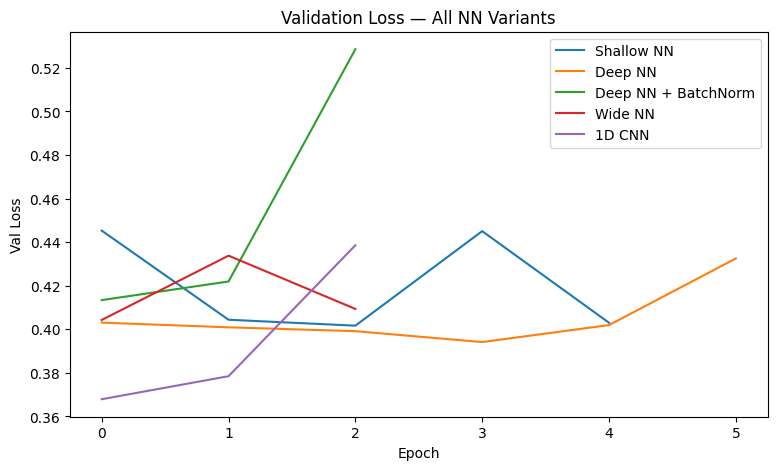

In [23]:
histories = {
    "Shallow NN": shallow_history,
    "Deep NN": deep_history,
    "Deep NN + BatchNorm": deep_bn_history,
    "Wide NN": wide_history,
    "1D CNN": cnn_history,
}

plt.figure(figsize=(9, 5))
for name, h in histories.items():
    plt.plot(h.history['val_loss'], label=name)
plt.title("Validation Loss — All NN Variants")
plt.xlabel("Epoch")
plt.ylabel("Val Loss")
plt.legend()
plt.savefig("nn_variants_val_loss_comparison.png")
plt.show()


# Part A — LSTM Baseline
A from-scratch embedding + Bidirectional LSTM, trained only on this dataset (no pretrained language knowledge). This is the pre-transformer comparison point — expect it to underperform DistilBERT, and that gap is exactly the result your report should highlight.

## A1) Keras Tokenization & Padding

In [24]:
VOCAB_SIZE = 20000
MAX_LEN = 128   # matches the word-length validation done above

keras_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
keras_tokenizer.fit_on_texts(train_reviews)

train_seq = keras_tokenizer.texts_to_sequences(train_reviews)
test_seq = keras_tokenizer.texts_to_sequences(test_reviews)

X_train_lstm = pad_sequences(train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_lstm = pad_sequences(test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print("X_train_lstm shape:", X_train_lstm.shape)
print("X_test_lstm shape:", X_test_lstm.shape)
print("Actual vocabulary size found:", len(keras_tokenizer.word_index))


X_train_lstm shape: (130276, 128)
X_test_lstm shape: (43426, 128)
Actual vocabulary size found: 43798


### Validate tokenization output
Decode a padded sequence back to words — confirms the Keras tokenizer + padding pipeline matches the original text, same validation approach used for DistilBERT below.

In [25]:
index_word = {v: k for k, v in keras_tokenizer.word_index.items()}

def decode_sequence(seq):
    return ' '.join(index_word.get(i, '') for i in seq if i != 0)

sample_idx = 0
print("Original text (first 300 chars):\n", train_reviews.iloc[sample_idx][:300])
print("\nDecoded back from padded sequence:\n", decode_sequence(X_train_lstm[sample_idx])[:300])
print("\nNon-zero (real) tokens in this padded sequence:", np.count_nonzero(X_train_lstm[sample_idx]))


Original text (first 300 chars):
 Stylish hotel great view from floor to ceiling window in 10th floor bedroom 

Decoded back from padded sequence:
 stylish hotel great view from floor to ceiling window in 10th floor bedroom

Non-zero (real) tokens in this padded sequence: 13


## A2) Build & Train the LSTM Model

In [26]:
EMBEDDING_DIM = 128

lstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy',
                    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

lstm_model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = lstm_model.fit(
    X_train_lstm, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1832/1832 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.8093 - auc: 0.8930 - loss: 0.4113 - val_accuracy: 0.8312 - val_auc: 0.9140 - val_loss: 0.3721
Epoch 2/10
1832/1832 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.8478 - auc: 0.9274 - loss: 0.3416 - val_accuracy: 0.8263 - val_auc: 0.9123 - val_loss: 0.3794
Epoch 3/10
1832/1832 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.8649 - auc: 0.9418 - loss: 0.3073 - val_accuracy: 0.8272 - val_auc: 0.9137 - val_loss: 0.3751


### Validate training — loss/accuracy curves

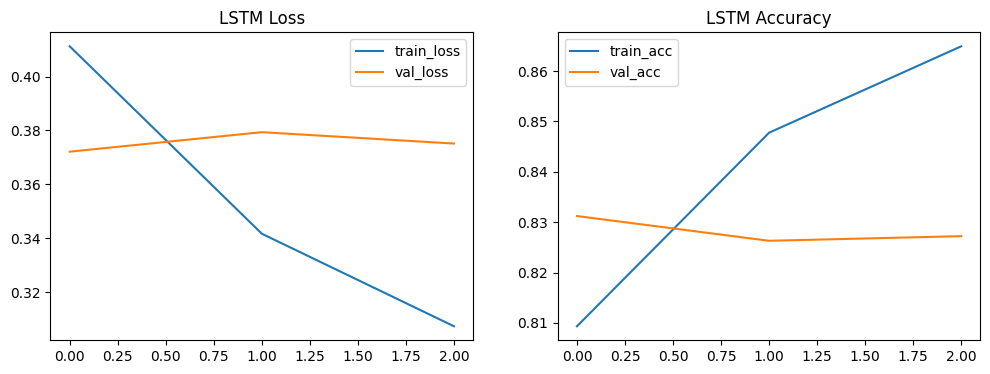

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train_loss')
axes[0].plot(history.history['val_loss'], label='val_loss')
axes[0].set_title('LSTM Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='train_acc')
axes[1].plot(history.history['val_accuracy'], label='val_acc')
axes[1].set_title('LSTM Accuracy')
axes[1].legend()

plt.savefig("lstm_training_curves.png")
plt.show()


## A3) LSTM Evaluation
Printed in the same log-loss / ROC-AUC / classification-report format your teammate's `model_predict()` uses, so this slots into the same comparison table.

In [28]:
lstm_probs = lstm_model.predict(X_test_lstm).flatten()
lstm_preds = (lstm_probs >= 0.5).astype(int)
lstm_probs_2class = np.column_stack([1 - lstm_probs, lstm_probs])

print("LSTM (Bidirectional) — Deep Learning Baseline\n")
print(f"logloss\n: {log_loss(y_test, lstm_probs_2class):0.3f}")
print(f"ROC AUC\n: {roc_auc_score(y_test, lstm_probs):0.3f}")
print("classification Report:\n", classification_report(y_test, lstm_preds))


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step
LSTM (Bidirectional) — Deep Learning Baseline

logloss
: 0.376
ROC AUC
: 0.913
classification Report:
               precision    recall  f1-score   support

           0       0.82      0.84      0.83     21722
           1       0.83      0.82      0.83     21704

    accuracy                           0.83     43426
   macro avg       0.83      0.83      0.83     43426
weighted avg       0.83      0.83      0.83     43426



# Part B — DistilBERT Fine-Tuning with LoRA
Pretrained transformer, fine-tuned with parameter-efficient LoRA adapters instead of full fine-tuning, for feasibility on a local machine. Compare its metrics against the LSTM above — the accuracy/F1 gap is the actual evidence for "why DL/transformers over a from-scratch RNN" in your report.

## B1) DistilBERT Tokenization

In [29]:
MODEL_NAME = "distil_bert_base_en_uncased"
MAX_LENGTH = 128

preprocessor = keras_hub.models.DistilBertTextClassifierPreprocessor.from_preset(
    MODEL_NAME,
    sequence_length=MAX_LENGTH,
)
print("Keras Hub DistilBERT preprocessor loaded.")

100%|██████████| 462/462 [00:00<00:00, 411kB/s]


100%|██████████| 794/794 [00:00<00:00, 1.29MB/s]


100%|██████████| 226k/226k [00:00<00:00, 267kB/s]


Keras Hub DistilBERT preprocessor loaded.


### Validate tokenization output
Decode a tokenized example back to text — confirms truncation/padding isn't silently corrupting the input.

In [30]:
sample_out = preprocessor([train_reviews.iloc[0]])
print("Original text (first 300 chars):\n", train_reviews.iloc[0][:300])
print("\nKeys:", sample_out.keys())
print("token_ids shape:", sample_out["token_ids"].shape)
print("padding_mask shape:", sample_out["padding_mask"].shape)
print("Non-padding tokens:", int(tf.reduce_sum(tf.cast(sample_out["padding_mask"], tf.int32))))

Original text (first 300 chars):
 Stylish hotel great view from floor to ceiling window in 10th floor bedroom 

Keys: dict_keys(['token_ids', 'padding_mask'])
token_ids shape: (1, 128)
padding_mask shape: (1, 128)
Non-padding tokens: 17


## B2) Build Hugging Face Dataset Objects

In [31]:
train_encodings = preprocessor(list(train_reviews))
test_encodings = preprocessor(list(test_reviews))

train_dataset = tf.data.Dataset.from_tensor_slices(
    (dict(train_encodings), list(y_train))
).batch(32).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (dict(test_encodings), list(y_test))
).batch(32).prefetch(tf.data.AUTOTUNE)

print(train_dataset)
print(test_dataset)

<_PrefetchDataset element_spec=({'token_ids': TensorSpec(shape=(None, 128), dtype=tf.int32, name=None), 'padding_mask': TensorSpec(shape=(None, 128), dtype=tf.bool, name=None)}, TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_PrefetchDataset element_spec=({'token_ids': TensorSpec(shape=(None, 128), dtype=tf.int32, name=None), 'padding_mask': TensorSpec(shape=(None, 128), dtype=tf.bool, name=None)}, TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


## B3) Load DistilBERT and Apply LoRA
Base weights frozen; only small rank-decomposition adapter matrices in the attention layers are trainable. The printed parameter count validates LoRA is actually active.

In [32]:
classifier = keras_hub.models.DistilBertTextClassifier.from_preset(
    MODEL_NAME,
    num_classes=2,
    preprocessor=None,   # preprocessing already done in the tf.data pipeline above
)

# Freezes all backbone weights, enables LoRA on the query & value
# attention projection layers only — Keras Hub's native equivalent
# of Hugging Face's peft LoraConfig
classifier.backbone.enable_lora(rank=8)

classifier.summary()   # confirm trainable param count dropped sharply

Model: "distil_bert_text_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ distil_bert_backbone          │ (None, None, 768)         │      67,253,760 │ padding_mask[0][0],        │
│ (DistilBertBackbone)          │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item (GetItem)            │ (None, 768)               │               0 │ distil_bert_backbone[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dense (Dense)          │ (None, 768)               │         590,592 │ get_item[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output_dropout (Dropout)      │ (None, 768)               │               0 │ pooled_dense[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 2)                 │           1,538 │ output_dropout[0][0]       │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 67,845,890 (258.81 MB)

 Trainable params: 1,492,226 (5.69 MB)

 Non-trainable params: 66,353,664 (253.12 MB)

## B4) Training

In [33]:
import keras
classifier.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.Adam(learning_rate=2e-4),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
)

history = classifier.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=3,
)

Epoch 1/3
4072/4072 ━━━━━━━━━━━━━━━━━━━━ 1383s 332ms/step - accuracy: 0.8205 - loss: 0.3908 - val_accuracy: 0.8350 - val_loss: 0.3602
Epoch 2/3
4072/4072 ━━━━━━━━━━━━━━━━━━━━ 1334s 328ms/step - accuracy: 0.8413 - loss: 0.3507 - val_accuracy: 0.8405 - val_loss: 0.3480
Epoch 3/3
4072/4072 ━━━━━━━━━━━━━━━━━━━━ 1333s 327ms/step - accuracy: 0.8495 - loss: 0.3358 - val_accuracy: 0.8440 - val_loss: 0.3423


## B5) DistilBERT Evaluation
Same log-loss / ROC-AUC / classification-report format as the LSTM above and your teammate's `model_predict()` — all three (ML, LSTM, DistilBERT) now compare directly.

In [34]:
raw_logits = classifier.predict(test_dataset)
probs = tf.nn.softmax(raw_logits, axis=1).numpy()
preds = np.argmax(probs, axis=1)

print("DistilBERT + LoRA (Keras Hub) — Deep Learning Model\n")
print(f"logloss\n: {log_loss(y_test, probs):0.3f}")
print(f"ROC AUC\n: {roc_auc_score(y_test, probs[:, 1]):0.3f}")
print("classification Report:\n", classification_report(y_test, preds))

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 185s 134ms/step
DistilBERT + LoRA (Keras Hub) — Deep Learning Model

logloss
: 0.342
ROC AUC
: 0.927
classification Report:
               precision    recall  f1-score   support

           0       0.84      0.85      0.85     21722
           1       0.85      0.83      0.84     21704

    accuracy                           0.84     43426
   macro avg       0.84      0.84      0.84     43426
weighted avg       0.84      0.84      0.84     43426



### Validate final output against ground truth
Spot-check predictions against actual labels and original text — confirms the full pipeline (tokenize -> model -> softmax -> argmax) is producing sane results, not just a good-looking metric.

In [35]:
check_df = pd.DataFrame({
    "review_snippet": [t[:120] for t in list(test_reviews)[:10]],
    "actual_label": [label_enc.classes_[l] for l in y_test[:10]],
    "predicted_label": [label_enc.classes_[p] for p in preds[:10]],
    "predicted_prob_good": probs[:10, 1].round(3)
})
check_df

,review_snippet,actual_label,predicted_label,predicted_prob_good
0,Location staff Asked for late checkout and did...,bad,bad,0.109
1,Good location rooftop pool new hotel nice balc...,good,good,0.602
2,Location service wifi spar we ordered food out...,good,good,0.728
3,Handy for Wembley stadium Quite pricey hotel p...,good,good,0.546
4,Great breakfast Great staff Amazing rooms Nice...,good,good,0.998
5,Easy to find Easy location No traffic noise in...,bad,bad,0.177
6,The room was good Location is good The staff w...,bad,bad,0.042
7,The staff members especially John were all ver...,good,good,0.981
8,comfy clean modern and friendly breakfast hotter,good,good,0.969
9,Swimming pool and comfort Troubles with ekectr...,bad,bad,0.103


# Final DL Comparison — LSTM vs. DistilBERT+LoRA
Consolidates both models' metrics side by side. This table is the direct evidence for the "why transformer over RNN" claim in your report.

In [36]:
# Best-performing NN variant included here; full NN variant table is in nn_comparison_df above
best_nn_row = nn_comparison_df.iloc[0].to_dict()

dl_comparison = pd.DataFrame([
    best_nn_row,
    {"Model": "LSTM (Bidirectional, from scratch)",
     "LogLoss": log_loss(y_test, lstm_probs_2class),
     "ROC_AUC": roc_auc_score(y_test, lstm_probs),
     "Accuracy": accuracy_score(y_test, lstm_preds),
     "F1_Macro": f1_score(y_test, lstm_preds, average='macro')},
    {"Model": "DistilBERT + LoRA",
     "LogLoss": log_loss(y_test, probs),
     "ROC_AUC": roc_auc_score(y_test, probs[:, 1]),
     "Accuracy": accuracy_score(y_test, preds),
     "F1_Macro": f1_score(y_test, preds, average='macro')},
])
dl_comparison


,Model,LogLoss,ROC_AUC,Accuracy,F1_Macro
0,1D CNN,0.367885,0.915108,0.832520,0.832448
1,"LSTM (Bidirectional, from scratch)",0.375774,0.912740,0.829549,0.829538
2,DistilBERT + LoRA,0.342329,0.927001,0.844011,0.843994


## Save Both Models

In [37]:
import pickle
import tempfile
import os

def model_to_bytes(model):
    """Serializes a Keras model to raw bytes via a temp file."""
    with tempfile.TemporaryDirectory() as tmp:
        path = os.path.join(tmp, "model.keras")
        model.save(path)
        with open(path, "rb") as f:
            return f.read()

# Serialize both trained models to bytes
lstm_bytes = model_to_bytes(lstm_model)
distilbert_bytes = model_to_bytes(classifier)  # Keras Hub classifier from Part B

# Bundle everything the chatbot/inference pipeline will need into ONE dict
chatbot_bundle = {
    "label_encoder": label_enc,
    "keras_tokenizer": keras_tokenizer,          # for LSTM/NN input prep
    "lstm_model_bytes": lstm_bytes,
    "distilbert_model_bytes": distilbert_bytes,
    "nn_comparison_df": nn_comparison_df,
    "dl_comparison": dl_comparison,
    "config": {
        "max_len": MAX_LEN,
        "vocab_size": VOCAB_SIZE,
        "distilbert_max_length": MAX_LENGTH,
        "distilbert_preset": MODEL_NAME,
    }
}

# Save to pickle file
with open("chatbot_model_bundle.pkl", "wb") as f:
    pickle.dump(chatbot_bundle, f)

print("✅ Saved single bundle -> chatbot_model_bundle.pkl")
print(f"Bundle size on disk: {os.path.getsize('chatbot_model_bundle.pkl') / (1024*1024):.2f} MB")


✅ Saved single bundle -> chatbot_model_bundle.pkl
Bundle size on disk: 299.25 MB


## Load Models from Pickle
**Run this cell in a fresh notebook/session to reload everything from the bundle.**

This reconstructs:
- Label encoder for sentiment classes
- Keras tokenizer for LSTM preprocessing
- LSTM model (from bytes)
- DistilBERT classifier (from bytes)
- Comparison DataFrames and config

In [38]:
# @title
import pickle
import tempfile
import os
import tensorflow as tf
import keras_hub

def bytes_to_model(model_bytes, custom_objects=None):
    """Reconstructs a Keras model from raw bytes via a temp file."""
    with tempfile.TemporaryDirectory() as tmp:
        path = os.path.join(tmp, "model.keras")
        with open(path, "wb") as f:
            f.write(model_bytes)
        return tf.keras.models.load_model(path, custom_objects=custom_objects)

# Load the entire bundle
with open("chatbot_model_bundle.pkl", "rb") as f:
    bundle = pickle.load(f)

# Extract each component
label_enc = bundle["label_encoder"]
keras_tokenizer = bundle["keras_tokenizer"]
config = bundle["config"]
nn_comparison_df = bundle["nn_comparison_df"]
dl_comparison = bundle["dl_comparison"]

# Reconstruct models from bytes
lstm_model = bytes_to_model(bundle["lstm_model_bytes"])
distilbert_classifier = bytes_to_model(bundle["distilbert_model_bytes"])

print("✅ Bundle loaded successfully!")
print(f"Reloaded label classes: {list(label_enc.classes_)}")
print(f"LSTM model input shape: {lstm_model.input_shape}")
print(f"DistilBERT classifier ready.")
print(f"Config: {config}")
print(f"\nComparison DataFrames available as: nn_comparison_df, dl_comparison")


/usr/local/lib/python3.12/dist-packages/keras/src/saving/serialization_lib.py:749: UserWarning: `compile()` was not called as part of model loading because the model's `compile()` method is custom. All subclassed Models that have `compile()` overridden should also override `get_compile_config()` and `compile_from_config(config)`. Alternatively, you can call `compile()` manually after loading.
  instance.compile_from_config(compile_config)


✅ Bundle loaded successfully!
Reloaded label classes: ['bad', 'good']
LSTM model input shape: (64, 128)
DistilBERT classifier ready.
Config: {'max_len': 128, 'vocab_size': 20000, 'distilbert_max_length': 128, 'distilbert_preset': 'distil_bert_base_en_uncased'}

Comparison DataFrames available as: nn_comparison_df, dl_comparison


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 82 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
